In [1]:
import numpy as np
import pandas as pd
import pickle

In [2]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding,Bidirectional,LSTM,Dropout,SpatialDropout1D,GRU

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [3]:
df=pickle.load(open('cleaned_df.pkl','rb'))
le=pickle.load(open('LabelEncoder.pkl','rb'))

In [4]:
text=df['lyrics_clean'].tolist()
labels=df['mood_enc'].tolist()


In [5]:
print(le.classes_)

['Angry' 'Calm' 'Happy' 'Sad']


In [27]:
MAX_WORDS=15000
MAX_LEN=150

In [28]:
tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token='<OOV>')

In [29]:
tokenizer.fit_on_texts(text)

In [30]:
print(len(tokenizer.word_index))

53380


In [31]:
Sequences=tokenizer.texts_to_sequences(text)


In [32]:
#3 Now Padding
X=pad_sequences(Sequences,maxlen=MAX_LEN,padding='pre',truncating='pre')

In [33]:
# Now doing Encoding
num_classes=len(le.classes_)
y=to_categorical(labels,num_classes)


In [15]:
import pickle
pickle.dump(tokenizer,open('Tokenizer.pkl','wb'))

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [35]:
print(X.shape)

(13691, 150)


In [36]:
y.shape

(13691, 4)

## Adding Class Weights because data is imbalaced a lot.

In [37]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [38]:
class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels

)
class_weight_dict=dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.6644826247330615), 1: np.float64(4.509552042160738), 2: np.float64(0.5548306046360837), 3: np.float64(2.1232940446650126)}


## Building the LSTM Model


In [39]:
from tensorflow.keras.layers import Conv1D

In [54]:
model=Sequential([
    Embedding(
        input_dim=MAX_WORDS,output_dim=128,input_length=MAX_LEN
    ),

    SpatialDropout1D(0.3),
    #3 It prevents overfitting
    
    Bidirectional(
        LSTM(128,return_sequences=True)
    ),
    Bidirectional(
        LSTM(64,return_sequences=False)
    ),
    
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dense(num_classes,activation='softmax')
])


c:\Users\Atharva\cs corner\ML_PROJECTS\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [55]:
model.build(input_shape=(None,MAX_LEN))

In [56]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 150, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 150, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,374,500 (9.06 MB)

 Trainable params: 2,374,500 (9.06 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [58]:
callbacks=EarlyStopping(
    monitor='val_loss',patience=5,restore_best_weights=True,verbose=1
)

In [60]:
history=model.fit(X_train,y_train,epochs=20,callbacks=callbacks,verbose=1,batch_size=64,class_weight=class_weight_dict)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 99s 574ms/step - accuracy: 0.2398 - loss: 1.3852
Epoch 2/20


c:\Users\Atharva\cs corner\ML_PROJECTS\venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 100s 583ms/step - accuracy: 0.2774 - loss: 1.3644
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 104s 604ms/step - accuracy: 0.3198 - loss: 1.2551
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 109s 635ms/step - accuracy: 0.4199 - loss: 1.0812
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 101s 585ms/step - accuracy: 0.5311 - loss: 0.8755
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 109s 634ms/step - accuracy: 0.6251 - loss: 0.6965
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 103s 600ms/step - accuracy: 0.6903 - loss: 0.5604
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 95s 553ms/step - accuracy: 0.7526 - loss: 0.4443
Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 106s 617ms/step - accuracy: 0.7858 - loss: 0.3963
Epoch 10/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 99s 574ms/step - accuracy: 0.7851 - loss: 0.3947
Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 100s 580ms/step - accuracy: 0.8191 - loss: 0.3372
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 98s 568ms/step - accuracy: 0.8470 - loss: 0.2847
Epoch 13/20
172/172 ━

In [61]:
y_pred=model.predict(X_test)
y_pred_classes=np.argmax(y_pred,axis=1)
y_test_classes=np.argmax(y_test,axis=1) 

86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step


In [62]:
print(classification_report(y_test_classes,y_pred_classes,target_names=le.classes_))

              precision    recall  f1-score   support

       Angry       0.44      0.41      0.42      1031
        Calm       0.09      0.09      0.09       152
       Happy       0.51      0.52      0.51      1234
         Sad       0.17      0.19      0.18       322

    accuracy                           0.42      2739
   macro avg       0.30      0.30      0.30      2739
weighted avg       0.42      0.42      0.42      2739



In [51]:
model.save('lstm_mood_model.keras')
model.save('lstm_mood_model47.keras')
model.save('lstm_mood_model40.keras')

In [52]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_classes,y_pred_classes)


<Axes: >

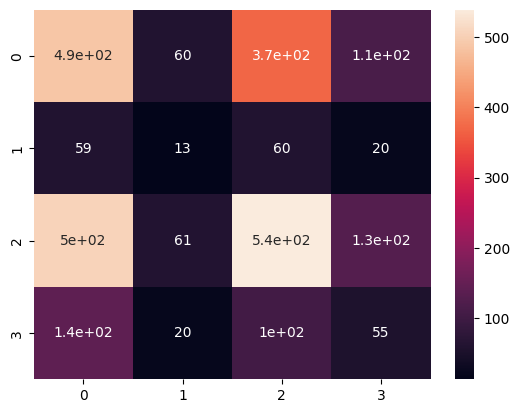

In [53]:
import seaborn as sns
sns.heatmap(cm,annot=True)

# I Noticed one thing that using lstm for mood detection is giving me wrong mood 
## so i decided to use VADER

In [4]:
from vaderSentiment.vaderSentiment import (
    SentimentIntensityAnalyzer
)

In [19]:
analyzer=SentimentIntensityAnalyzer()

In [20]:
def mood_detect_vader(user_text,df,top_n=5):
    scores=analyzer.polarity_scores(user_text)
    compound=scores['compound']
    pos=scores['pos']
    neg=scores['neg']

    print(f"scores:{scores}")

    # Map to mood
    if compound >= 0.3:
        mood='Happy'
    elif compound <= -0.3 and pos < 0.1:
        mood='Sad'
    elif compound <= -0.1 and pos > 0.1:
        mood='Angry'
    else:
        mood='Calm'
    
    confidence = round(abs(compound) * 100,1)

    filtered=df[df['mood'] == mood]
    if len(filtered) < top_n:
        filtered=df
    results=filtered.sample(
        min(top_n,len(filtered))
    )[['track_name','track_artist','mood']]
    return results,mood,confidence



In [30]:
results,mood,conf=mood_detect_vader(
    "I am feeling happy and energetic today!",df
)

print(f"Detected: {mood} ({conf}%)")
print(results)

scores:{'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'compound': 0.8122}
Detected: Happy (81.2%)
                       track_name     track_artist   mood
4938              We Can Freak It           Kurupt  Happy
12221  Come Clean - E New Y Radio  Jeru The Damaja  Happy
5087                Never Go Back     Dennis Lloyd  Happy
8468                    Ridin Big      Pastor Troy  Happy
10465    Shotgun (The Wild Remix)      George Ezra  Happy


## Now all things are dump succesfully so we will move to app.py